imports

In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import  sklearn

# data cleaning and explorationn

load data

In [2]:
app_df = pd.read_csv(r"C:\Users\malak\DataspellProjects\Credit Card Approval Prediction\application_record.csv")
credit_df = pd.read_csv(r"C:\Users\malak\DataspellProjects\Credit Card Approval Prediction\credit_record.csv")

In [3]:
app_df.head(5)

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0


In [4]:
credit_df.head(5)


,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C


## data cleaning

### null values

In [5]:
# NULL values
print("Application Record - Nulls:\n", app_df.isnull().sum())
print("\nCredit Record - Nulls:\n", credit_df.isnull().sum())



Application Record - Nulls:
 ID                          0
CODE_GENDER                 0
FLAG_OWN_CAR                0
FLAG_OWN_REALTY             0
CNT_CHILDREN                0
AMT_INCOME_TOTAL            0
NAME_INCOME_TYPE            0
NAME_EDUCATION_TYPE         0
NAME_FAMILY_STATUS          0
NAME_HOUSING_TYPE           0
DAYS_BIRTH                  0
DAYS_EMPLOYED               0
FLAG_MOBIL                  0
FLAG_WORK_PHONE             0
FLAG_PHONE                  0
FLAG_EMAIL                  0
OCCUPATION_TYPE        134203
CNT_FAM_MEMBERS             0
dtype: int64

Credit Record - Nulls:
 ID                0
MONTHS_BALANCE    0
STATUS            0
dtype: int64


### duplicates values

In [6]:
# DUPLICATES
print("\nApplication Record - Duplicates:", app_df.duplicated().sum())
print("Credit Record - Duplicates:", credit_df.duplicated().sum())


Application Record - Duplicates: 0
Credit Record - Duplicates: 0


### check data types

In [7]:
print(app_df.info())
print(credit_df.info())



<class 'pandas.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   438557 non-null  int64  
 1   CODE_GENDER          438557 non-null  str    
 2   FLAG_OWN_CAR         438557 non-null  str    
 3   FLAG_OWN_REALTY      438557 non-null  str    
 4   CNT_CHILDREN         438557 non-null  int64  
 5   AMT_INCOME_TOTAL     438557 non-null  float64
 6   NAME_INCOME_TYPE     438557 non-null  str    
 7   NAME_EDUCATION_TYPE  438557 non-null  str    
 8   NAME_FAMILY_STATUS   438557 non-null  str    
 9   NAME_HOUSING_TYPE    438557 non-null  str    
 10  DAYS_BIRTH           438557 non-null  int64  
 11  DAYS_EMPLOYED        438557 non-null  int64  
 12  FLAG_MOBIL           438557 non-null  int64  
 13  FLAG_WORK_PHONE      438557 non-null  int64  
 14  FLAG_PHONE           438557 non-null  int64  
 15  FLAG_EMAIL           438557 

## fixing  values

In [8]:
app_df['OCCUPATION_TYPE'] = app_df['OCCUPATION_TYPE'].fillna('Other')

In [9]:
app_df.head(5)

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,Other,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,Other,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0


In [10]:
app_df['AGE'] = (app_df['DAYS_BIRTH'].abs() / 365).astype(int)
app_df.drop(columns=['DAYS_BIRTH'], inplace=True)

In [11]:
app_df.head(5)



,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,AGE
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-4542,1,1,0,0,Other,2.0,32
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-4542,1,1,0,0,Other,2.0,32
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-1134,1,0,0,0,Security staff,2.0,58
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-3051,1,0,1,1,Sales staff,1.0,52
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-3051,1,0,1,1,Sales staff,1.0,52


In [12]:
app_df.head(5)


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,AGE
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-4542,1,1,0,0,Other,2.0,32
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-4542,1,1,0,0,Other,2.0,32
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-1134,1,0,0,0,Security staff,2.0,58
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-3051,1,0,1,1,Sales staff,1.0,52
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-3051,1,0,1,1,Sales staff,1.0,52


## handling outliers

In [13]:
import numpy as np

app_df['AMT_INCOME_TOTAL'] = np.log1p(app_df['AMT_INCOME_TOTAL'])

In [14]:
def cap_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[column] = df[column].clip(lower, upper)
    return df

In [15]:
app_df = cap_outliers(app_df, 'AMT_INCOME_TOTAL')

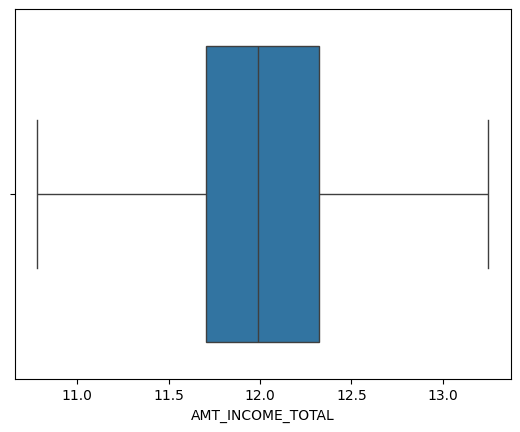

In [16]:
sns.boxplot(x=app_df['AMT_INCOME_TOTAL'])
plt.show()

## create traget

In [17]:
payment_summary = credit_df.groupby('ID').agg(
    late_count=('STATUS', lambda x: (x.isin(['1','2','3','4','5'])).sum()),
    severe_count=('STATUS', lambda x: (x.isin(['3','4','5'])).sum())
).reset_index()

In [18]:
df = pd.merge(app_df, payment_summary, on='ID', how='left')

In [19]:
# Payment behavior
df['SCORE_NO_LATE'] = (df['late_count'] == 0).astype(int)
df['SCORE_NO_SEVERE'] = (df['severe_count'] == 0).astype(int)

# Employment
df['SCORE_EMPLOYED'] = (df['DAYS_EMPLOYED'] < 0).astype(int)
df['SCORE_STABLE_JOB'] = (df['DAYS_EMPLOYED'] < -730).astype(int)

# Income
df['SCORE_INCOME'] = (df['AMT_INCOME_TOTAL'] > df['AMT_INCOME_TOTAL'].median()).astype(int)

# Stability
df['SCORE_MARRIED'] = (df['NAME_FAMILY_STATUS'] == 'Married').astype(int)
df['SCORE_AGE'] = (df['AGE'] > 25).astype(int)
df['SCORE_CHILDREN'] = (df['CNT_CHILDREN'] <= 2).astype(int)

In [20]:
score_cols = [
    'SCORE_NO_LATE',
    'SCORE_NO_SEVERE',
    'SCORE_EMPLOYED',
    'SCORE_STABLE_JOB',
    'SCORE_INCOME',
    'SCORE_MARRIED',
    'SCORE_AGE',
    'SCORE_CHILDREN'
]

df['RISK_SCORE_RAW'] = df[score_cols].sum(axis=1)

In [21]:
df['RISK_SCORE'] = df['RISK_SCORE_RAW'] / 8

In [22]:
df[['RISK_SCORE_RAW', 'RISK_SCORE']].head()

,RISK_SCORE_RAW,RISK_SCORE
0,6,0.750
1,6,0.750
2,7,0.875
3,7,0.875
4,7,0.875


In [23]:
df.head(5)

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,...,SCORE_NO_LATE,SCORE_NO_SEVERE,SCORE_EMPLOYED,SCORE_STABLE_JOB,SCORE_INCOME,SCORE_MARRIED,SCORE_AGE,SCORE_CHILDREN,RISK_SCORE_RAW,RISK_SCORE
0,5008804,M,Y,Y,0,12.965712,Working,Higher education,Civil marriage,Rented apartment,...,0,1,1,1,1,0,1,1,6,0.750
1,5008805,M,Y,Y,0,12.965712,Working,Higher education,Civil marriage,Rented apartment,...,0,1,1,1,1,0,1,1,6,0.750
2,5008806,M,Y,Y,0,11.630717,Working,Secondary / secondary special,Married,House / apartment,...,1,1,1,1,0,1,1,1,7,0.875
3,5008808,F,N,Y,0,12.506181,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,...,1,1,1,1,1,0,1,1,7,0.875
4,5008809,F,N,Y,0,12.506181,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,...,1,1,1,1,1,0,1,1,7,0.875


In [24]:
df['TARGET'] = (df['RISK_SCORE'] >= 0.6).astype(int)

In [25]:
print(df[['RISK_SCORE', 'TARGET']].head())
print(df['TARGET'].value_counts())

   RISK_SCORE  TARGET
0       0.750       1
1       0.750       1
2       0.875       1
3       0.875       1
4       0.875       1
TARGET
1    281198
0    157359
Name: count, dtype: int64


In [28]:
# Import required libraries
from sklearn.model_selection import train_test_split
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd



Features: 47
Samples: 438557

Train: 350845 samples
Test: 87712 samples

BAGGING ENSEMBLE MODEL RESULTS
Accuracy: 0.9774147209047793

Classification Report:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97     31472
           1       1.00      0.97      0.98     56240

    accuracy                           0.98     87712
   macro avg       0.97      0.98      0.98     87712
weighted avg       0.98      0.98      0.98     87712


Confusion Matrix:
[[31400    72]
 [ 1909 54331]]


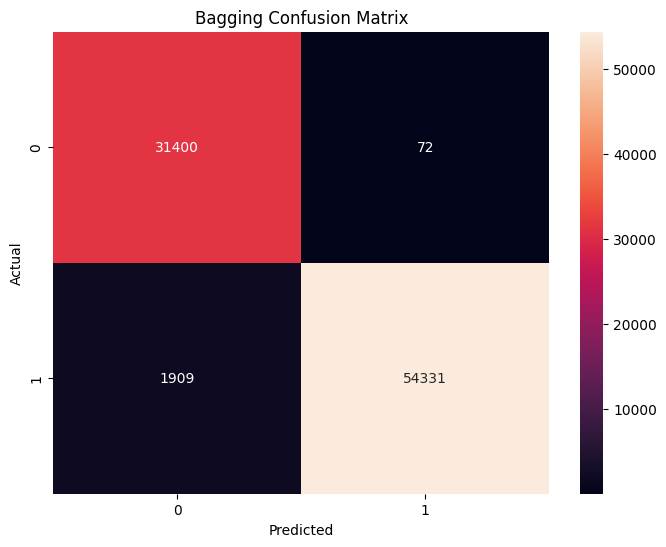

In [30]:
df_model = df.copy()

# DROP COLUMNS (prevent leakage)
drop_cols = ['ID', 'late_count', 'severe_count', 'RISK_SCORE', 'RISK_SCORE_RAW'] + score_cols
df_model.drop(columns=drop_cols, inplace=True)

# One-hot encode categorical
df_model = pd.get_dummies(df_model, drop_first=True)

# Separate X and y
X = df_model.drop(['TARGET'], axis=1)
y = df_model['TARGET']

print(f"\nFeatures: {X.shape[1]}")
print(f"Samples: {X.shape[0]}")

# ============================================================
# TRAIN-TEST SPLIT
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain: {X_train.shape[0]} samples")
print(f"Test: {X_test.shape[0]} samples")

# ============================================================
# TRAIN BAGGING ENSEMBLE MODEL
# ============================================================
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

model = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=15),
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# ============================================================
# RESULTS
# ============================================================
print("\n" + "="*60)
print("BAGGING ENSEMBLE MODEL RESULTS")
print("="*60)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

# Plot
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Bagging Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


Features: 47
Samples: 438557

Train: 350845 samples
Test: 87712 samples

XGBOOST ENSEMBLE MODEL RESULTS
Accuracy: 0.9736638088288946

Classification Report:
              precision    recall  f1-score   support

           0       0.93      1.00      0.96     31472
           1       1.00      0.96      0.98     56240

    accuracy                           0.97     87712
   macro avg       0.97      0.98      0.97     87712
weighted avg       0.98      0.97      0.97     87712


Confusion Matrix:
[[31463     9]
 [ 2301 53939]]


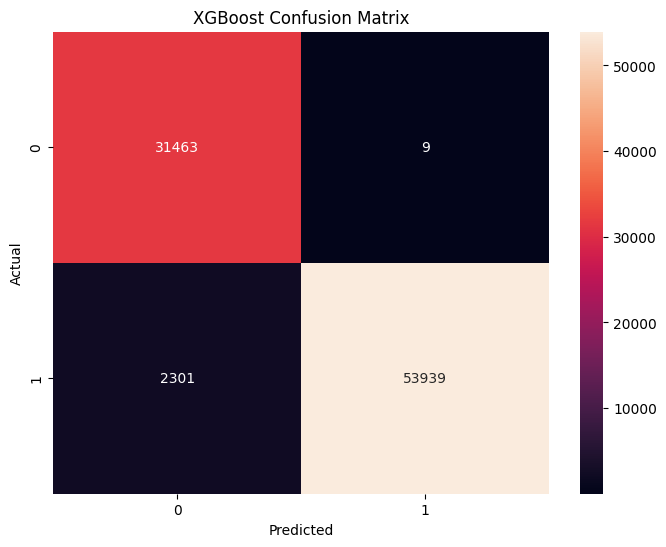

In [34]:
df_model = df.copy()

# DROP COLUMNS (prevent leakage)
drop_cols = ['ID', 'late_count', 'severe_count', 'RISK_SCORE', 'RISK_SCORE_RAW'] + score_cols
df_model.drop(columns=drop_cols, inplace=True)

# One-hot encode categorical
df_model = pd.get_dummies(df_model, drop_first=True)

# Separate X and y
X = df_model.drop(['TARGET'], axis=1)
y = df_model['TARGET']

print(f"\nFeatures: {X.shape[1]}")
print(f"Samples: {X.shape[0]}")

# ============================================================
# TRAIN-TEST SPLIT
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain: {X_train.shape[0]} samples")
print(f"Test: {X_test.shape[0]} samples")

# ============================================================
# TRAIN XGBOOST ENSEMBLE MODEL
# ============================================================
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1])
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# ============================================================
# RESULTS
# ============================================================
print("\n" + "="*60)
print("XGBOOST ENSEMBLE MODEL RESULTS")
print("="*60)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

# Plot
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()